Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,369 (2.48 MB)

 Trainable params: 650,369 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5043 - loss: 0.6971 - val_accuracy: 0.5161 - val_loss: 0.6917
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.5165 - loss: 0.6957 - val_accuracy: 0.5906 - val_loss: 0.6568
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.5701 - loss: 0.6675 - val_accuracy: 0.5694 - val_loss: 0.6659
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.5748 - loss: 0.6537 - val_accuracy: 0.5290 - val_loss: 0.6841
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.5540 - loss: 0.6696 - val_accuracy: 0.5828 - val_loss: 0.6454
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.6229 - loss: 0.6046 - val_accuracy: 0.6093 - val_loss: 0.6328
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.6325 - loss: 0.5890 - val_accuracy: 0.5822 - val_loss: 0.6365
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.6411 - loss: 0.5776 - 

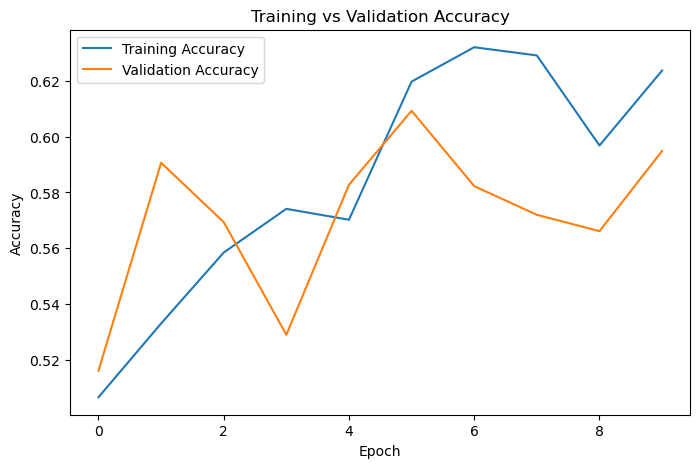

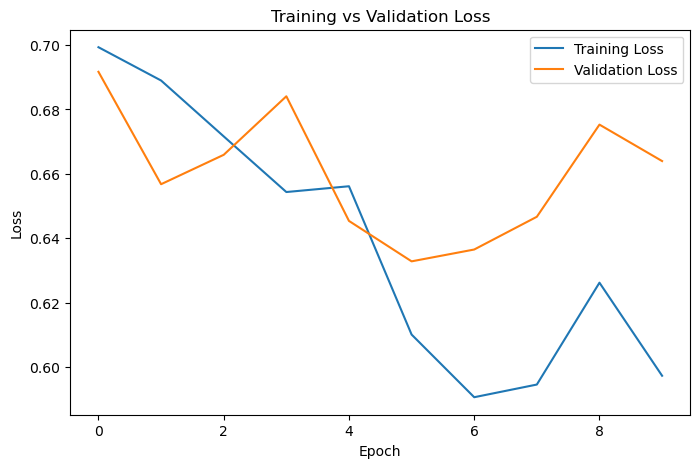

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5819 - loss: 0.6617
Final Test Loss: 0.6633284091949463
Final Test Accuracy (%): 58.469998836517334


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input

# Load dataset
df = pd.read_csv(r"Z:\Applied AI\IMDB Dataset.csv")

# Encode labels (positive=1, negative=0)
encoder = LabelEncoder()
df['sentiment'] = encoder.fit_transform(df['sentiment'])

# Text data
reviews = df['review'].astype(str)
labels = df['sentiment']

# Tokenization
vocab_size = 10000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(reviews)

sequences = tokenizer.texts_to_sequences(reviews)

# Padding
max_length = 200
X = pad_sequences(sequences, maxlen=max_length, padding='post')

y = np.array(labels)

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train / Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# Embedding dimension
embedding_dim = 64

model = Sequential([
    Input(shape=(max_length,)),

    Embedding(vocab_size, embedding_dim),

    SimpleRNN(64),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Final Test Loss:", test_loss)
print("Final Test Accuracy (%):", test_accuracy * 100)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,382,977 (5.28 MB)

 Trainable params: 1,382,977 (5.28 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 85ms/step - accuracy: 0.5371 - loss: 0.7080 - val_accuracy: 0.5874 - val_loss: 0.6951
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 81ms/step - accuracy: 0.7467 - loss: 0.5439 - val_accuracy: 0.8266 - val_loss: 0.4621
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 84ms/step - accuracy: 0.8796 - loss: 0.3304 - val_accuracy: 0.8656 - val_loss: 0.3327
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - accuracy: 0.9248 - loss: 0.2322 - val_accuracy: 0.8815 - val_loss: 0.3361
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 85ms/step - accuracy: 0.9474 - loss: 0.1701 - val_accuracy: 0.8611 - val_loss: 0.3603


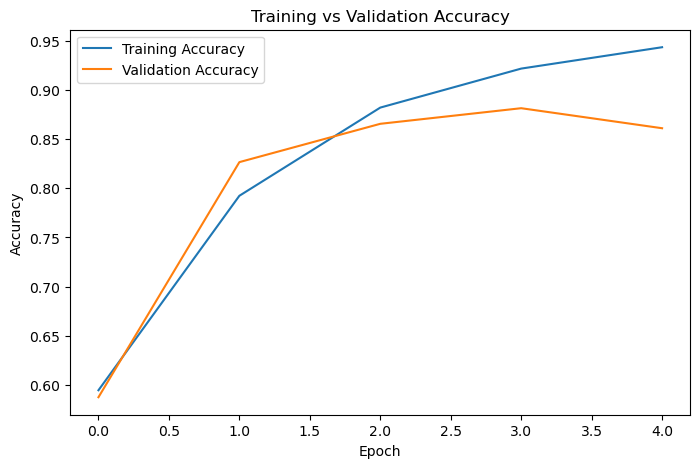

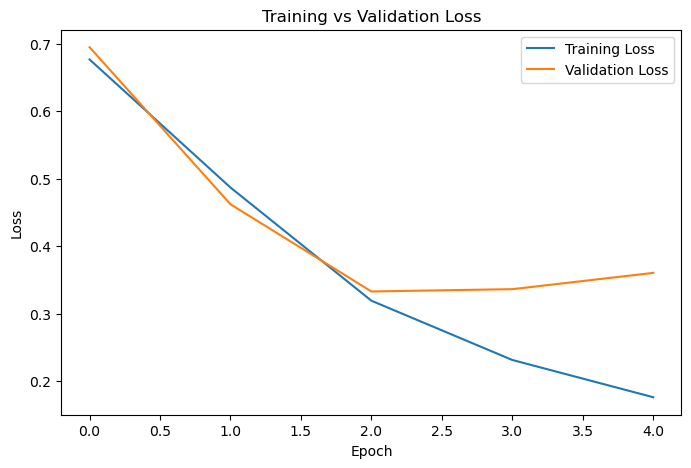

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8593 - loss: 0.3354
Final Test Loss: 0.33244964480400085
Final Test Accuracy (%): 86.22000217437744


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# Load dataset
df = pd.read_csv(r"Z:\Applied AI\IMDB Dataset.csv")

# Encode labels
encoder = LabelEncoder()
df['sentiment'] = encoder.fit_transform(df['sentiment'])

# Text and labels
reviews = df['review'].astype(str)
labels = df['sentiment']

# Tokenization
vocab_size = 10000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(reviews)

sequences = tokenizer.texts_to_sequences(reviews)

# Padding
max_length = 200
X = pad_sequences(sequences, maxlen=max_length, padding='post')

y = np.array(labels)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train/Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# Model parameters
embedding_dim = 128

# Build model
model = Sequential([

    Input(shape=(max_length,)),

    Embedding(vocab_size, embedding_dim),

    Bidirectional(LSTM(64, return_sequences=False)),

    Dropout(0.5),

    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),

    Dropout(0.5),

    Dense(1, activation='sigmoid')

])

model.summary()

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# Train model
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

# Plot Accuracy
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot Loss
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Final Test Loss:", test_loss)
print("Final Test Accuracy (%):", test_accuracy * 100)